In [1]:
import os
from pathlib import Path

# Le notebook vit dans notebooks/ — on se replace à la racine du projet
# pour que tous les chemins relatifs de config.yaml (data/raw, models/...) soient corrects.
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Répertoire de travail :", Path.cwd())

Répertoire de travail : /home/ronanguilloueee/FIFACast


### Chargement des données

In [2]:
import pandas as pd
from src.config import load_config
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
color = ["#FE0162", "#345FFF", "#0ECDD0", "#F6970A", "#0B155B"]


CONFIG = load_config()
DATA_URL = CONFIG["external"]["match_result"]["csv_url"]
df = pd.read_csv(DATA_URL)


### Analyse du dataset

In [3]:
print(f"Number of rows/columns: {df.shape}")

print(f"Describe :")
display(df.describe(include='all'))

print(f"NaN values :")
missing_content = (df.isnull().sum()/len(df)*100).to_frame("%")    #uniquement pour une pbseries
display(missing_content[missing_content["%"]!=0])

print(f"Top 5 :")
display(df.head(5))

Number of rows/columns: (49520, 9)
Describe :


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49520,49520,49520,49518.000000,49518.000000,49520,49520,49520,49520
unique,16491,328,322,NaN,NaN,201,2092,269,2
top,2012-02-29,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,66,618,585,NaN,NaN,18387,745,1585,36364
mean,NaN,NaN,NaN,1.757179,1.182338,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.773730,1.401927,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN


NaN values :


,%
home_score,0.004039
away_score,0.004039


Top 5 :


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### Outliers

In [4]:
df = df.dropna(subset=["home_score", "away_score"])
df["total_goals"] = (df["home_score"] + df["away_score"]).astype(int)

high_band   = df["total_goals"].mean() + df["total_goals"].std()*3
low_band    = df["total_goals"].mean() - df["total_goals"].std()*3

salary_outlier_index = df[~((df["total_goals"] > low_band) & (df["total_goals"] < high_band))]
display(salary_outlier_index)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
19,1882-02-18,Northern Ireland,England,0.0,13.0,Friendly,Belfast,Ireland,False,13
37,1885-03-14,Scotland,Northern Ireland,8.0,2.0,British Home Championship,Glasgow,Scotland,False,10
40,1885-04-11,Northern Ireland,Wales,2.0,8.0,British Home Championship,Belfast,Ireland,False,10
56,1888-03-03,Wales,Northern Ireland,11.0,0.0,British Home Championship,Wrexham,Wales,False,11
59,1888-03-24,Northern Ireland,Scotland,2.0,10.0,British Home Championship,Belfast,Ireland,False,12
...,...,...,...,...,...,...,...,...,...,...
48513,2025-07-14,Isle of Man,Frøya,10.0,1.0,Island Games,Dounby,Scotland,True,11
48676,2025-09-09,Norway,Moldova,11.0,1.0,FIFA World Cup qualification,Oslo,Norway,False,12
48715,2025-10-09,Austria,San Marino,10.0,0.0,FIFA World Cup qualification,Vienna,Austria,False,10
48947,2025-11-16,Portugal,Armenia,9.0,1.0,FIFA World Cup qualification,Porto,Portugal,False,10


### Distribution du nombre de buts

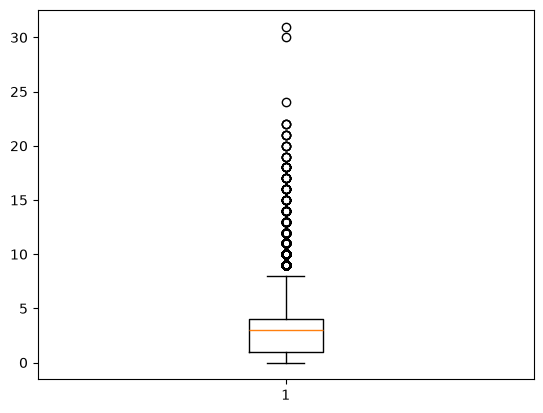

In [7]:
plt.boxplot(df['total_goals'].dropna())
plt.show()

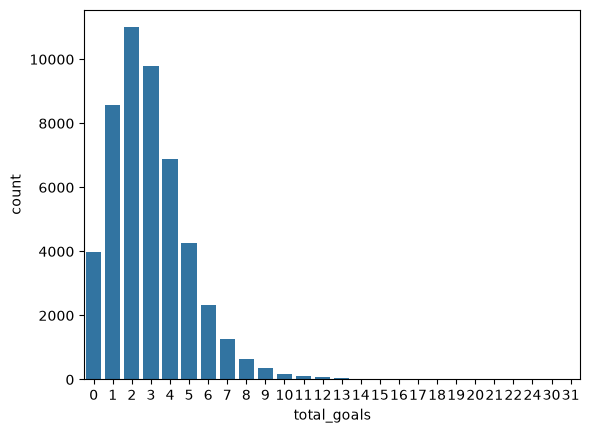

In [8]:
sns.countplot(x='total_goals', data=df)
plt.show()

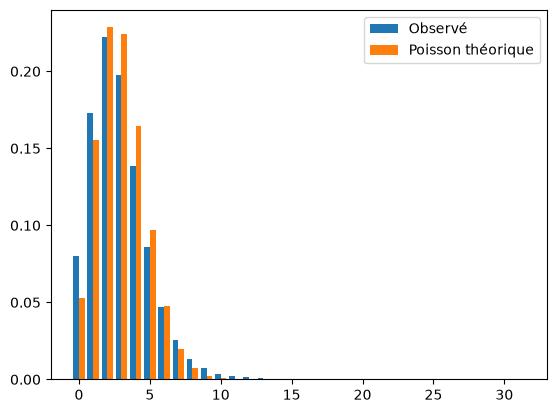

In [9]:
from scipy.stats import poisson
import numpy as np

mu = df['total_goals'].mean()
x = np.arange(0, df['total_goals'].max()+1)
plt.bar(x - 0.2, df['total_goals'].value_counts(normalize=True).reindex(x, fill_value=0), width=0.4, label='Observé')
plt.bar(x + 0.2, poisson.pmf(x, mu), width=0.4, label='Poisson théorique')
plt.legend()
plt.show()